Here we will try and replicate the Wigner semicicle law, and see if we can get it. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#we will begin by creating a wigner matrix. 
# we need two i.i.d. families of random variables. They must be centered, and the second one must have finite second 
# which we call t

def generate_random_matrix(N):
    M = np.zeros((N,N)) # empty matrix of size N
    
    # diagonal
    P = np.random.poisson(lam=1, size=N)
    Y = P - 1
    for i in range(N):
        M[i,i]=Y[i] / np.sqrt(N)

    # off diagonal
    for i in range(N):
        for j in range(i+1, N):
            B = np.random.binomial(n=10, p=0.5)
            Z = (B - 5) / np.sqrt(N)

            M[i,j] = Z
            M[j,i] = Z

    return M

In [15]:
matrix = generate_random_matrix(10000)
eigs, _ = np.linalg.eigh(matrix)
print(eigs)

KeyboardInterrupt: 

/var/folders/sr/ymfbnl3d2kj679w5x3g12vgc0000gn/T/ipykernel_43859/19626355.py:6: RuntimeWarning: invalid value encountered in sqrt
  sigma = lambda x, t: (1 / 2 * np.pi * t) * np.sqrt((4 * t - x**2))


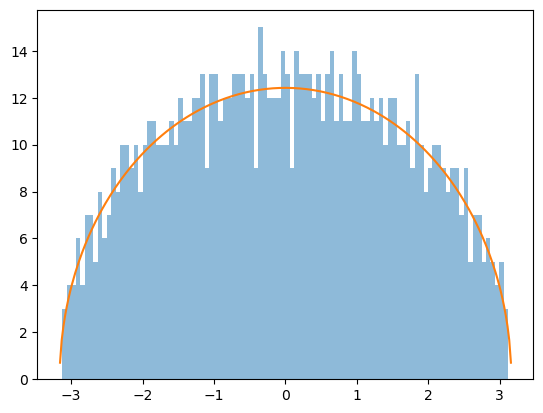

In [14]:
# in the above, t=2.5
t=2.5

plt.hist(eigs, bins=100, alpha=0.5)
x = np.linspace(-t * np.sqrt(2), t * np.sqrt(2), 300)
sigma = lambda x, t: (1 / 2 * np.pi * t) * np.sqrt((4 * t - x**2))
y = sigma(x, t)
plt.plot(x,y)
plt.show()

We can see it works as expected! We just have the scale the prediction based on the eigenvalues!